# AUTOENCODERS - UNET

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


In [ ]:
#@title **Load libraries**
#@markdown Here is important to change to GPU

import os
import cv2
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm_notebook, tnrange

from itertools import chain
from skimage.morphology import label
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from skimage.io import imread, imshow, concatenate_images

import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import concatenate, add
from tensorflow.keras.layers import Lambda, RepeatVector, Reshape
from tensorflow.keras.layers import Conv2D, Conv2DTranspose
from tensorflow.keras.layers import MaxPooling2D, GlobalMaxPool2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Input, BatchNormalization, Activation, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator  #img_to_array, array_to_img, load_img

# **1. Semantic segmentation** <a name="Semant_seg"></a>

Image classification gives a **discrete labeled answer (image dimension)** from an image input with **objects of interest** into a particular scene. This task is much more complex, including localization, detection, and spatial object boundary.

For **_semantic segmentation_** specifically the task is associated **to each pixel** with a semantic label produced by a machine learning algorithm. This task is known as a **dense prediction** and the result is useful for many different scenarios, areas and applications. In figure you can observe applications related with **autonomous vehicles** for planning and detection of traffic signs, to support **biomedical image diagnosis**, for **agriculture precision** to reduce herbicides and smart control.

<center>
<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-2-uis-student/-/raw/master/imgs/segmentation.png" style="width:700px;heigth:100px">
</center>

Nowadays, there exist more sophisticated models that try **instance segmentation** with the idea to obtain a per-pixel segmentation but for **multiclass** problems.

# **2. UNET: an autoencoder to segmentation** <a name="Unet"></a>

### **The architecture of UNET**

<center>
<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-2-uis-student/-/raw/master/imgs/unet.png"  width="700">
</center>
So, how looks an UNET-code... **go to the action!**

In [ ]:
#@title **Coding** Create the pair of UNET convolutions
def conv2d_block(input_tensor, n_filters, kernel_size = 3, batchnorm = True):
    """Function to add 2 convolutional layers with the parameters passed to it"""
    # First layer
    x = Conv2D(filters = n_filters, kernel_size = (kernel_size, kernel_size),\
              kernel_initializer = 'he_normal', padding = 'same')(input_tensor)
    if batchnorm:
        x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Second layer
    x = Conv2D(filters = n_filters, kernel_size = (kernel_size, kernel_size),\
              kernel_initializer = 'he_normal', padding = 'same')(input_tensor)
    if batchnorm:
        x = BatchNormalization()(x)
    x = Activation('relu')(x)

    return x


In [ ]:
 #@title **Coding** A nice UNET function
 def get_unet(input_img, n_filters = 16, dropout = 0.1, batchnorm = True):

    # Contracting Path
    c1 = conv2d_block(input_img, n_filters * 1, kernel_size = 3, batchnorm = batchnorm)
    p1 = MaxPooling2D((2, 2))(c1)
    p1 = Dropout(dropout)(p1)

    c2 = conv2d_block(p1, n_filters * 2, kernel_size = 3, batchnorm = batchnorm)
    p2 = MaxPooling2D((2, 2))(c2)
    p2 = Dropout(dropout)(p2)

    c3 = conv2d_block(p2, n_filters * 4, kernel_size = 3, batchnorm = batchnorm)
    p3 = MaxPooling2D((2, 2))(c3)
    p3 = Dropout(dropout)(p3)

    c4 = conv2d_block(p3, n_filters * 8, kernel_size = 3, batchnorm = batchnorm)
    p4 = MaxPooling2D((2, 2))(c4)
    p4 = Dropout(dropout)(p4)

    c5 = conv2d_block(p4, n_filters = n_filters * 16, kernel_size = 3, batchnorm = batchnorm)

    # Expansive Path
    u6 = Conv2DTranspose(n_filters * 8, (3, 3), strides = (2, 2), padding = 'same')(c5)
    u6 = concatenate([u6, c4])
    u6 = Dropout(dropout)(u6)
    c6 = conv2d_block(u6, n_filters * 8, kernel_size = 3, batchnorm = batchnorm)

    u7 = Conv2DTranspose(n_filters * 4, (3, 3), strides = (2, 2), padding = 'same')(c6)
    u7 = concatenate([u7, c3])
    u7 = Dropout(dropout)(u7)
    c7 = conv2d_block(u7, n_filters * 4, kernel_size = 3, batchnorm = batchnorm)

    u8 = Conv2DTranspose(n_filters * 2, (3, 3), strides = (2, 2), padding = 'same')(c7)
    u8 = concatenate([u8, c2])
    u8 = Dropout(dropout)(u8)
    c8 = conv2d_block(u8, n_filters * 2, kernel_size = 3, batchnorm = batchnorm)

    u9 = Conv2DTranspose(n_filters * 1, (3, 3), strides = (2, 2), padding = 'same')(c8)
    u9 = concatenate([u9, c1])
    u9 = Dropout(dropout)(u9)
    c9 = conv2d_block(u9, n_filters * 1, kernel_size = 3, batchnorm = batchnorm)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)
    model = Model(inputs=[input_img], outputs=[outputs])
    return model

# **3. UNET application 1**  <a name="Unet_1"></a>
### **Nuclei segmentation**

A very important task is automate nucleus detection and segmentation. The task of classifying, identifying, and segmenting cell nuclei is very important in many clinical tasks, such as: quantifying disorders, diseases related to cancer, understand treatment responses, among others. The image data was taken from [data-science-bowl-2018](https://www.kaggle.com/c/data-science-bowl-2018)

<center>
<img src="https://storage.googleapis.com/kaggle-media/competitions/dsb-2018/dsb.jpg" width="700">
</center>





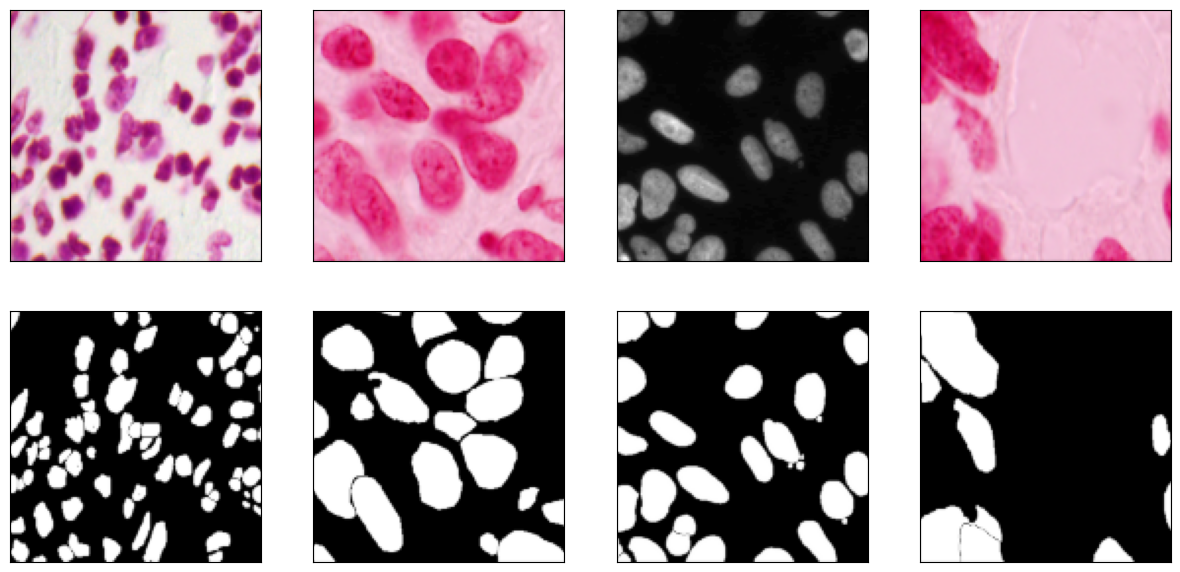

In [ ]:
#@title **Coding** Let's show some examples
path = '/content/drive/MyDrive/AUTOMATAS/IA2/Notebooks/data_segmentation/bowl-2018/'

plt.figure(figsize=(15,15))
plt.subplot(441), plt.imshow(cv2.imread(os.path.join(path,'imgs', '71.png'))), plt.xticks([]), plt.yticks([]);
plt.subplot(442), plt.imshow(cv2.imread(os.path.join(path,'imgs', '68.png'))), plt.xticks([]), plt.yticks([]);
plt.subplot(443), plt.imshow(cv2.imread(os.path.join(path,'imgs', '94.png'))),plt.xticks([]), plt.yticks([]);
plt.subplot(444), plt.imshow(cv2.imread(os.path.join(path,'imgs', '114.png'))),plt.xticks([]), plt.yticks([]);
plt.subplot(445), plt.imshow(cv2.imread(os.path.join(path,'masks', '71.png'))), plt.xticks([]), plt.yticks([]);
plt.subplot(446), plt.imshow(cv2.imread(os.path.join(path,'masks', '68.png'))), plt.xticks([]), plt.yticks([]);
plt.subplot(447), plt.imshow(cv2.imread(os.path.join(path,'masks', '94.png'))),plt.xticks([]), plt.yticks([]);
plt.subplot(448), plt.imshow(cv2.imread(os.path.join(path,'masks', '114.png'))),plt.xticks([]), plt.yticks([]);


In [ ]:
#@title **Coding** To load the dataset
# path = '/content/drive/My Drive/main/academic/courses/2020-UIS-MachineAnsDeepLearning/ai-2-uis-professor/data/bowl-2018/'
# Create each array of the images and the corresponding mask
imgs_l = []; masks_l =[]

# List them all
imgs = os.listdir(path + 'imgs')
masks = os.listdir(path + 'masks')

# Time to sort
imgs.sort(); masks.sort()

# How can we obtain each path?
imgs = [os.path.join(path, 'imgs', img) for img in imgs]
masks = [os.path.join(path, 'masks', mask) for mask in masks]

# Load each image
imgs_l = [cv2.imread(img) for img in imgs]
masks_l = [cv2.imread(mask,0) for mask in masks]

# Normalize all the data
print("Images: ", len(imgs_l), "Masks: ",  len(masks_l), "Shape of an specific image: ", imgs_l[0].shape)
X = np.array(imgs_l)/255.0
y = np.array(masks_l)/255.0
print("X samples value: ", X.shape, "Y samples value: ", y.shape, "Max value on X: ", np.max(X), "Min value on X", np.min(X))
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.1, random_state=42)

Images:  670 Masks:  670 Shape of an specific image:  (128, 128, 3)
X samples value:  (670, 128, 128, 3) Y samples value:  (670, 128, 128) Max value on X:  1.0 Min value on X 0.0


In [ ]:
#@title **Coding** Charge, prepare and tune the model
input_img = Input((128, 128, 3), name='img')
model = get_unet(input_img, n_filters=16, dropout=0.05, batchnorm=True)
model.compile(optimizer=Adam(), loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 img (InputLayer)            [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 conv2d_1 (Conv2D)           (None, 128, 128, 16)         448       ['img[0][0]']                 
                                                                                                  
 batch_normalization_1 (Bat  (None, 128, 128, 16)         64        ['conv2d_1[0][0]']            
 chNormalization)                                                                                 
                                                                                                  
 activation_1 (Activation)   (None, 128, 128, 16)         0         ['batch_normalization_1[0]

In [ ]:
#@title **Coding** Time to train the model! :)
earlystopper = EarlyStopping(patience=3, verbose=1)
checkpointer = ModelCheckpoint('model_cell_unet.h5', verbose=1, save_best_only=True)
results = model.fit(X_train, y_train, batch_size=32,
                    callbacks=[earlystopper, checkpointer],
                    epochs=50,validation_data=(X_valid, y_valid))


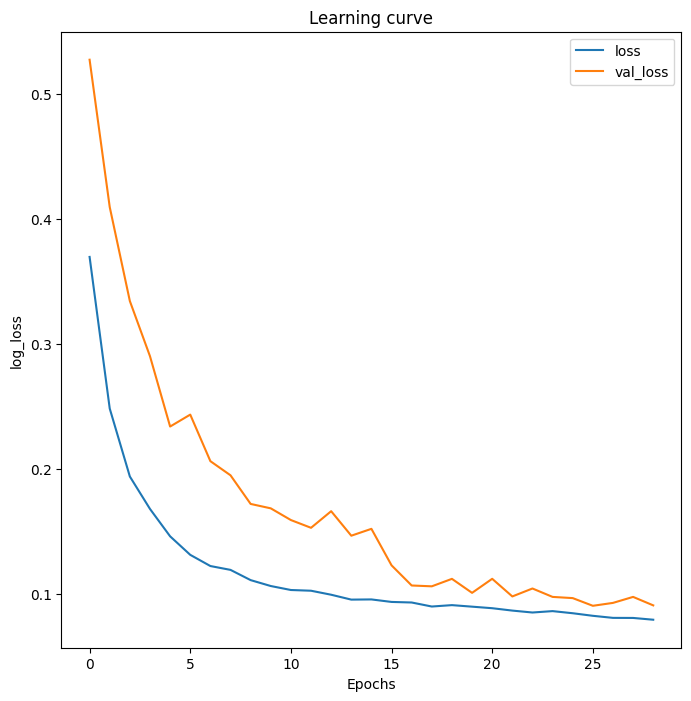

In [ ]:
#@title **Coding** To show train and test performance
plt.figure(figsize=(8, 8))
plt.title("Learning curve")
plt.plot(results.history["loss"], label="loss")
plt.plot(results.history["val_loss"], label="val_loss")
plt.xlabel("Epochs")
plt.ylabel("log_loss")
plt.legend();

In [ ]:
# If the model takes too long:
new_model2 = tf.keras.models.load_model('models/model_cell_unet.h5')

In [ ]:
#@title **Coding** What about each prediction?
preds_train = model.predict(X_train, verbose=1)
preds_val = model.predict(X_valid, verbose=1)

preds_val.shape, preds_train.shape
# Threshold predictions
preds_train_t = (preds_train > 0.5).astype(np.uint8)
preds_val_t = (preds_val > 0.5).astype(np.uint8)

3/3 [==============================] - 0s 14ms/step


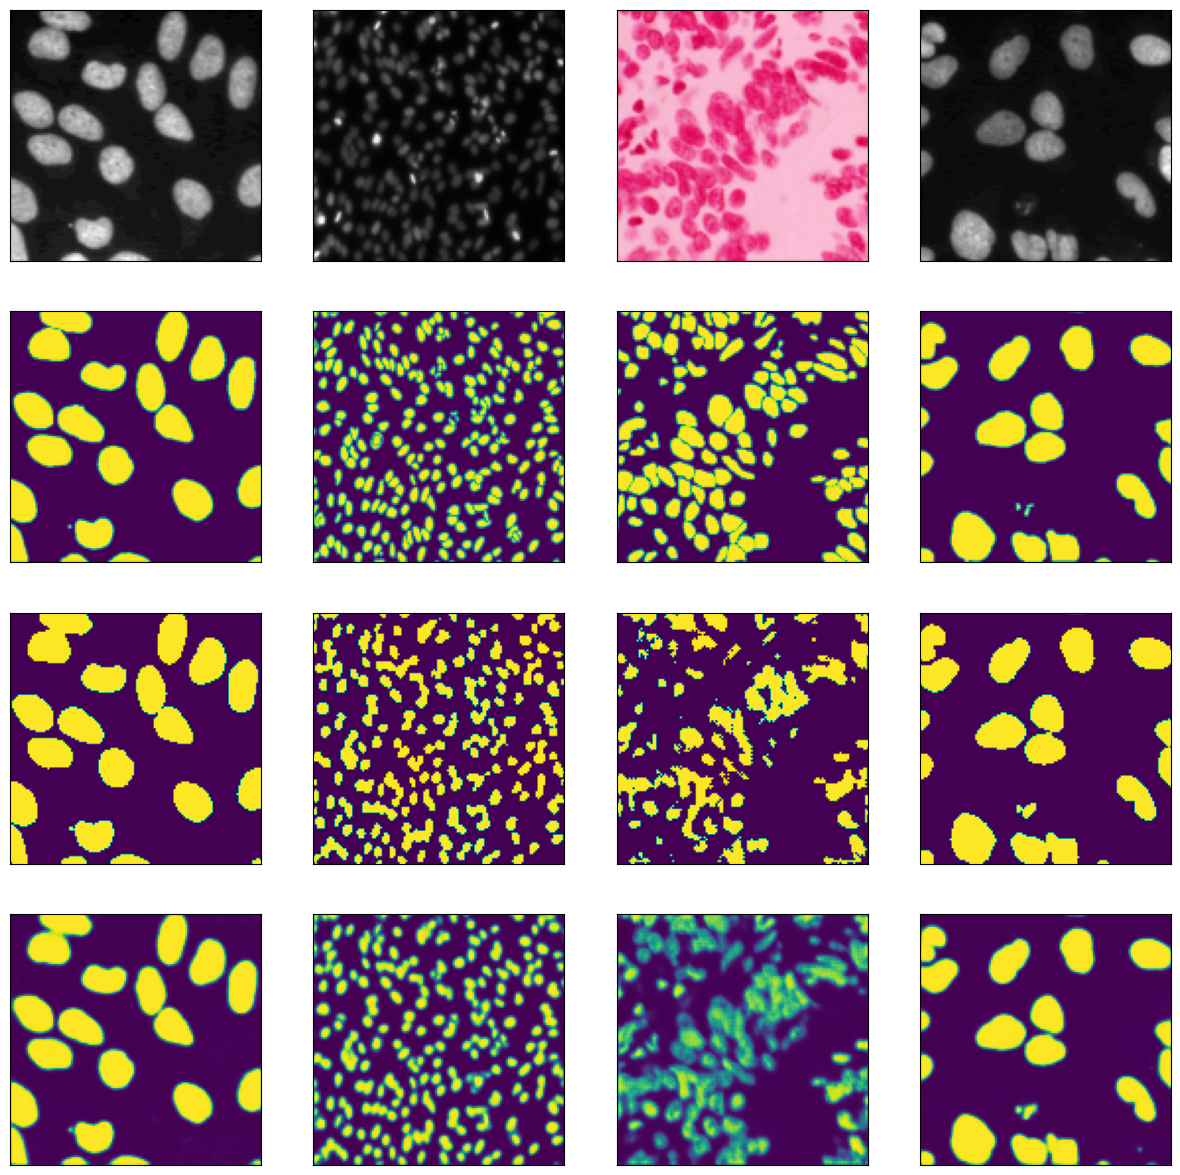

In [ ]:
#@title **Coding** Some results
ex_1 = 21 #@param {type:"integer"}
ex_2 = 15 #@param {type:"integer"}
ex_3 = 23 #@param {type:"integer"}
ex_4 =  0 #@param {type:"integer"}

plt.figure(figsize=(15,15))

plt.subplot(441), plt.imshow(X_valid[ex_1]), plt.xticks([]), plt.yticks([]);
plt.subplot(442), plt.imshow(X_valid[ex_2]), plt.xticks([]), plt.yticks([]);
plt.subplot(443), plt.imshow(X_valid[ex_3]), plt.xticks([]), plt.yticks([]);
plt.subplot(444), plt.imshow(X_valid[ex_4]), plt.xticks([]), plt.yticks([]);

plt.subplot(445), plt.imshow(y_valid[ex_1]), plt.xticks([]), plt.yticks([]);
plt.subplot(446), plt.imshow(y_valid[ex_2]), plt.xticks([]), plt.yticks([]);
plt.subplot(447), plt.imshow(y_valid[ex_3]), plt.xticks([]), plt.yticks([]);
plt.subplot(448), plt.imshow(y_valid[ex_4]), plt.xticks([]), plt.yticks([]);

plt.subplot(449), plt.imshow(np.squeeze(preds_val_t[ex_1])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,10), plt.imshow(np.squeeze(preds_val_t[ex_2])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,11), plt.imshow(np.squeeze(preds_val_t[ex_3])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,12), plt.imshow(np.squeeze(preds_val_t[ex_4])), plt.xticks([]), plt.yticks([]);

plt.subplot(4,4,13), plt.imshow(np.squeeze(preds_val[ex_1])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,14), plt.imshow(np.squeeze(preds_val[ex_2])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,15), plt.imshow(np.squeeze(preds_val[ex_3])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,16), plt.imshow(np.squeeze(preds_val[ex_4])), plt.xticks([]), plt.yticks([]);

<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-2-uis-student/-/raw/master/imgs/icon1.png" width="200">

- Try a more restrictive data learning. Only take 50 % and 20% of training data. Visualize and analyze the results. What happened?

# **4. UNET application 2** <a name="Unet_2"></a>


Seismic data is captured from seismic reflection, similar to X-ray, sonar and echolocation. In this dataset is collected a set of images that try to detect several areas of the world where there are vast quantities of salt in the subsurface. The sequence of images was taken from the dataset [tgs-salt-identification-challenge](https://www.kaggle.com/c/tgs-salt-identification-challenge/data)


In [ ]:
# @title **Coding** We need to visualize segmentation challenge

path = '/content/drive/MyDrive/UIS/Courses/2020-UIS-MachineAnsDeepLearning/ai-2-uis-professor/data/tgsalt/'

plt.figure(figsize=(15,10))
ax1= plt.subplot(441), plt.imshow(cv2.imread(os.path.join(path,'imgs', '711.png'),0)), plt.xticks([]), plt.yticks([]);
ax1= plt.contour(cv2.imread(os.path.join(path,'masks', '711.png'),0), colors='k', levels=[0.5]);
ax2= plt.subplot(442), plt.imshow(cv2.imread(os.path.join(path,'imgs', '618.png'),0)), plt.xticks([]), plt.yticks([]);
ax2= plt.contour(cv2.imread(os.path.join(path,'masks', '618.png'),0), colors='k', levels=[0.5]);
ax3=plt.subplot(443), plt.imshow(cv2.imread(os.path.join(path,'imgs', '914.png'),0)),plt.xticks([]), plt.yticks([]);
ax3= plt.contour(cv2.imread(os.path.join(path,'masks', '914.png'),0), colors='k', levels=[0.5]);
ax4=plt.subplot(444), plt.imshow(cv2.imread(os.path.join(path,'imgs', '1114.png'),0)),plt.xticks([]), plt.yticks([]);
ax4= plt.contour(cv2.imread(os.path.join(path,'masks', '1114.png'),0), colors='k', levels=[0.5]);
ax5=plt.subplot(445), plt.imshow(cv2.imread(os.path.join(path,'masks', '711.png'),0)), plt.xticks([]), plt.yticks([]);
ax6=plt.subplot(446), plt.imshow(cv2.imread(os.path.join(path,'masks', '618.png'),0)), plt.xticks([]), plt.yticks([]);
ax7=plt.subplot(447), plt.imshow(cv2.imread(os.path.join(path,'masks', '914.png'),0)),plt.xticks([]), plt.yticks([]);
ax8=plt.subplot(448), plt.imshow(cv2.imread(os.path.join(path,'masks', '1114.png'),0)),plt.xticks([]), plt.yticks([]);


In [ ]:
#@title **Coding** To load the dataset
# path = '/content/drive/MyDrive/UIS/Courses/2020-UIS-MachineAnsDeepLearning/ai-2-uis-professor/data/tgsalt/'
# Create each array of the images and the corresponding mask
imgs_l = []; masks_l =[]

# List them all
imgs = os.listdir(path + 'imgs')
masks = os.listdir(path + 'masks')

# Time to sort
imgs.sort(); masks.sort()

# How can we obtain each path?
imgs = [os.path.join(path, 'imgs', img) for img in imgs]
masks = [os.path.join(path, 'masks', mask) for mask in masks]

# Load each image
imgs_l = [cv2.imread(img) for img in imgs]
masks_l = [cv2.imread(mask,0) for mask in masks]

# Normalize all the data
print("Images: ", len(imgs_l), "Masks: ",  len(masks_l), "Shape of an specific image: ", imgs_l[0].shape)
X = np.array(imgs_l)/255.0
y = np.array(masks_l)/255.0
print("X samples value: ", X.shape, "Y samples value: ", y.shape, "Max value on X: ", np.max(X), "Min value on X", np.min(X))
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.1, random_state=42)

Images:  4000 Masks:  4000 Shape of an specific image:  (128, 128, 3)
X samples value:  (4000, 128, 128, 3) Y samples value:  (4000, 128, 128) Max value on X:  1.0 Min value on X 0.0


In [ ]:
# @title **Coding** Time to load a pre-trained unet model
model = tf.keras.models.load_model('models/model_tgsalt_unet.h5')
model.summary()

Model: "functional_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 img (InputLayer)               [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_20 (Conv2D)             (None, 128, 128, 16  448         ['img[0][0]']                    
                                )                                                                 
                                                                                                  
 batch_normalization_19 (BatchN  (None, 128, 128, 16  64         ['conv2d_20[0][0]']              
 ormalization)                  )                                                      

In [ ]:
#@title **Coding** What if we need to predict?
preds_train = model.predict(X_train, verbose=1)
preds_val = model.predict(X_valid, verbose=1)

preds_val.shape, preds_train.shape
# Threshold predictions
preds_train_t = (preds_train > 0.5).astype(np.uint8)
preds_val_t = (preds_val > 0.5).astype(np.uint8)

13/13 [==============================] - 0s 16ms/step


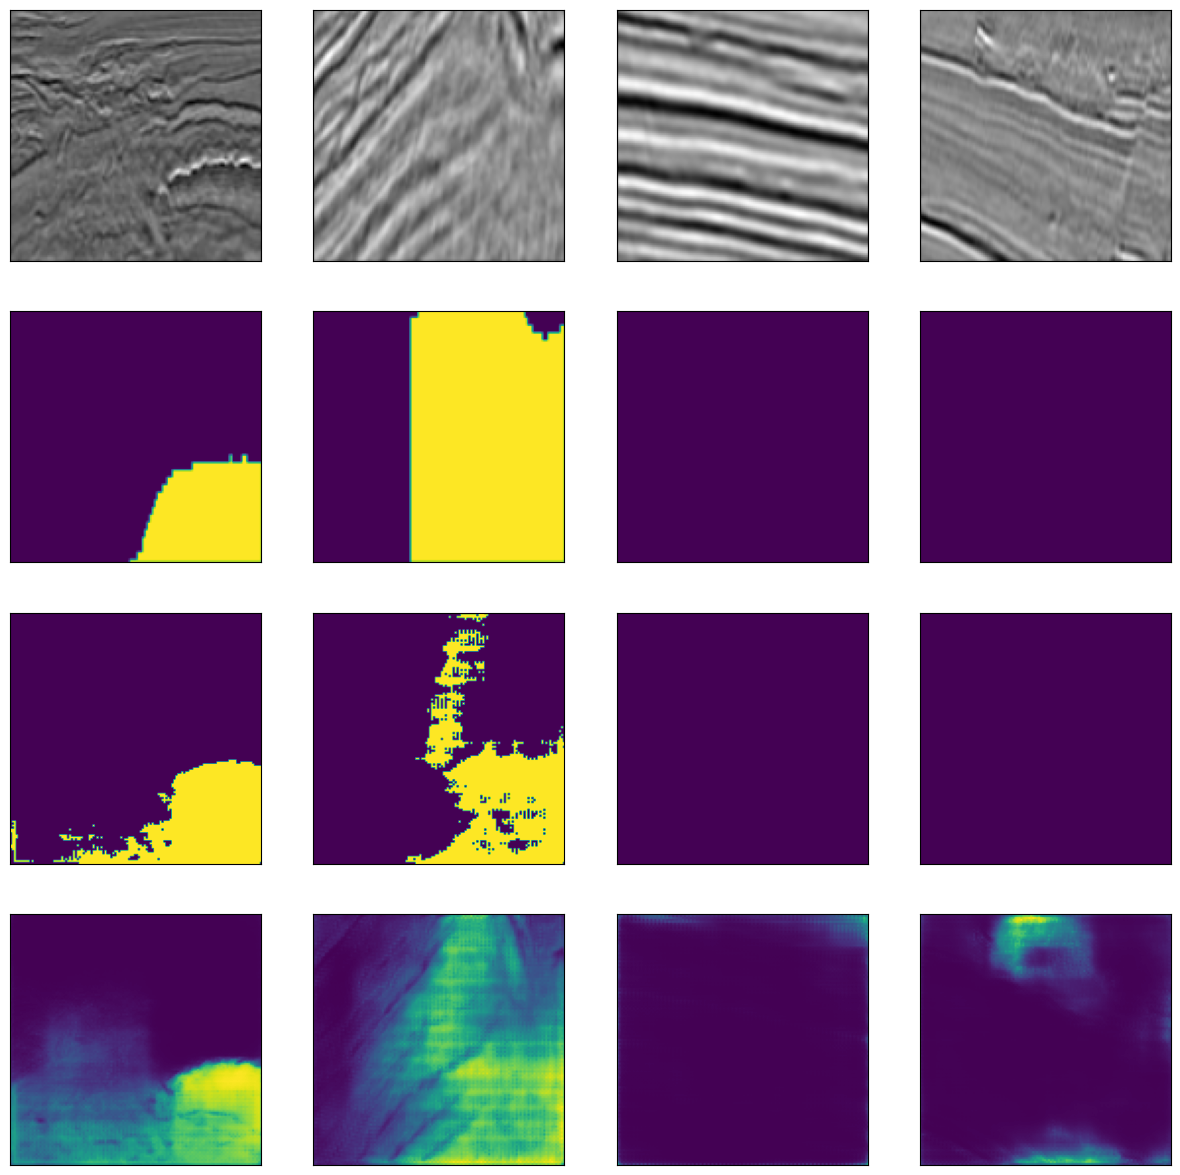

In [ ]:
#@title **code** Some visual results
ex_1 =  21#@param {type:"integer"}
ex_2 = 15 #@param {type:"integer"}
ex_3 = 23 #@param {type:"integer"}
ex_4 =  300#@param {type:"integer"}

plt.figure(figsize=(15,15))

plt.subplot(441), plt.imshow(X_valid[ex_1]), plt.xticks([]), plt.yticks([]);
plt.subplot(442), plt.imshow(X_valid[ex_2]), plt.xticks([]), plt.yticks([]);
plt.subplot(443), plt.imshow(X_valid[ex_3]), plt.xticks([]), plt.yticks([]);
plt.subplot(444), plt.imshow(X_valid[ex_4]), plt.xticks([]), plt.yticks([]);

plt.subplot(445), plt.imshow(y_valid[ex_1]), plt.xticks([]), plt.yticks([]);
plt.subplot(446), plt.imshow(y_valid[ex_2]), plt.xticks([]), plt.yticks([]);
plt.subplot(447), plt.imshow(y_valid[ex_3]), plt.xticks([]), plt.yticks([]);
plt.subplot(448), plt.imshow(y_valid[ex_4]), plt.xticks([]), plt.yticks([]);

plt.subplot(449), plt.imshow(np.squeeze(preds_val_t[ex_1])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,10), plt.imshow(np.squeeze(preds_val_t[ex_2])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,11), plt.imshow(np.squeeze(preds_val_t[ex_3])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,12), plt.imshow(np.squeeze(preds_val_t[ex_4])), plt.xticks([]), plt.yticks([]);

plt.subplot(4,4,13), plt.imshow(np.squeeze(preds_val[ex_1])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,14), plt.imshow(np.squeeze(preds_val[ex_2])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,15), plt.imshow(np.squeeze(preds_val[ex_3])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,16), plt.imshow(np.squeeze(preds_val[ex_4])), plt.xticks([]), plt.yticks([]);

<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-2-uis-student/-/raw/master/imgs/icon1.png" width="200">

- Evaluate other images and enjoy!
- put contours over images to analyze model perfomance




In [ ]:
#@title **Student code:** If we have time ...To load the complete dataset
#@markdown if not, please run to homework
"""
Put your code here
"""

In [ ]:
#@title **Student code** Charge, prepare and tune the model
"""
Put your code here
"""


In [ ]:
#@title **Student code** Time to train the model!
"""
Put your code here
"""


In [ ]:
#@title **Student code** Time to show train and test performance
"""
Put your code here
"""

In [ ]:
#@title **Code** What about the prediction?
preds_train = model.predict(X_train, verbose=1)
preds_val = model.predict(X_valid, verbose=1)

preds_val.shape, preds_train.shape
# Threshold predictions
preds_train_t = (preds_train > 0.5).astype(np.uint8)
preds_val_t = (preds_val > 0.5).astype(np.uint8)

13/13 [==============================] - 0s 17ms/step


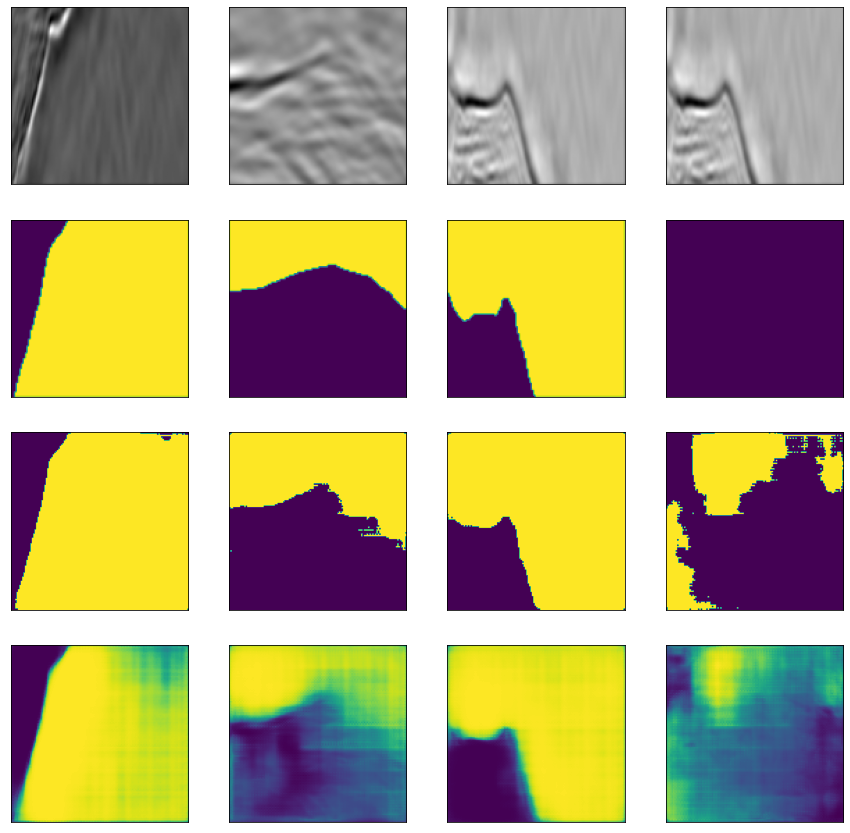

In [ ]:
#@title **Coding** Some results
ex_1 =  21#@param {type:"integer"}
ex_2 = 15 #@param {type:"integer"}
ex_3 = 23 #@param {type:"integer"}
ex_4 =  0#@param {type:"integer"}

plt.figure(figsize=(15,15))

plt.subplot(441), plt.imshow(X_valid[ex_1]), plt.xticks([]), plt.yticks([]);
plt.subplot(442), plt.imshow(X_valid[ex_2]), plt.xticks([]), plt.yticks([]);
plt.subplot(443), plt.imshow(X_valid[ex_3]), plt.xticks([]), plt.yticks([]);
plt.subplot(444), plt.imshow(X_valid[ex_3]), plt.xticks([]), plt.yticks([]);

plt.subplot(445), plt.imshow(y_valid[ex_1]), plt.xticks([]), plt.yticks([]);
plt.subplot(446), plt.imshow(y_valid[ex_2]), plt.xticks([]), plt.yticks([]);
plt.subplot(447), plt.imshow(y_valid[ex_3]), plt.xticks([]), plt.yticks([]);
plt.subplot(448), plt.imshow(y_valid[ex_4]), plt.xticks([]), plt.yticks([]);

plt.subplot(449), plt.imshow(np.squeeze(preds_val_t[ex_1])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,10), plt.imshow(np.squeeze(preds_val_t[ex_2])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,11), plt.imshow(np.squeeze(preds_val_t[ex_3])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,12), plt.imshow(np.squeeze(preds_val_t[ex_4])), plt.xticks([]), plt.yticks([]);

plt.subplot(4,4,13), plt.imshow(np.squeeze(preds_val[ex_1])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,14), plt.imshow(np.squeeze(preds_val[ex_2])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,15), plt.imshow(np.squeeze(preds_val[ex_3])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,16), plt.imshow(np.squeeze(preds_val[ex_4])), plt.xticks([]), plt.yticks([]);

<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-2-uis-student/-/raw/master/imgs/icon1.png" width="200">

Run the model with whole images, built your own model, and try with different configurations.

- Try to test the model with two different data configurations.
  - The first experiment only takes 50% of the data for training, while the second experiment takes 80 % for training.
  - Use a different optimizer, epochs, and other parameters
- Propose a new architecture with different layers, change set of neurons and with different dropout



# **Some conclusions**

- Nowadays, the UNet is one of the most representative architectures to segment images from a deep learning perspective, with impressive results in many areas.

- Of course, there exist many variations of this architecture to solve some segmentation challenges.

- Also, there exist other tasks are recognition, multiple instance segmentation that requires more sophisticated nets.

# **References**

[1. U-Net: Convolutional Networks for Biomedical
Image Segmentation](https://arxiv.org/pdf/1505.04597.pdf)


[2. A guide to convolution arithmetic for deep learning](https://arxiv.org/abs/1603.07285)

[3. Deconvolution and Checkerboard Artifacts](https://distill.pub/2016/deconv-checkerboard/)

[4. Transposed convolution](https://medium.com/activating-robotic-minds/up-sampling-with-transposed-convolution-9ae4f2df52d0)

<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/cv/cv-uis-student/raw/master/imgs/bannerThanks.jpg" style="width:1000px;">